# Ames Housing - XGBoost

## Import Libraires and Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

## Import and inspect base dataframe

In [3]:
base_df = pd.read_csv('AmesHousing.csv')

In [4]:
base_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [7]:
base_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


## Exploratory Data Analysis

### Plot Distribution of Sales Price - Target Variable

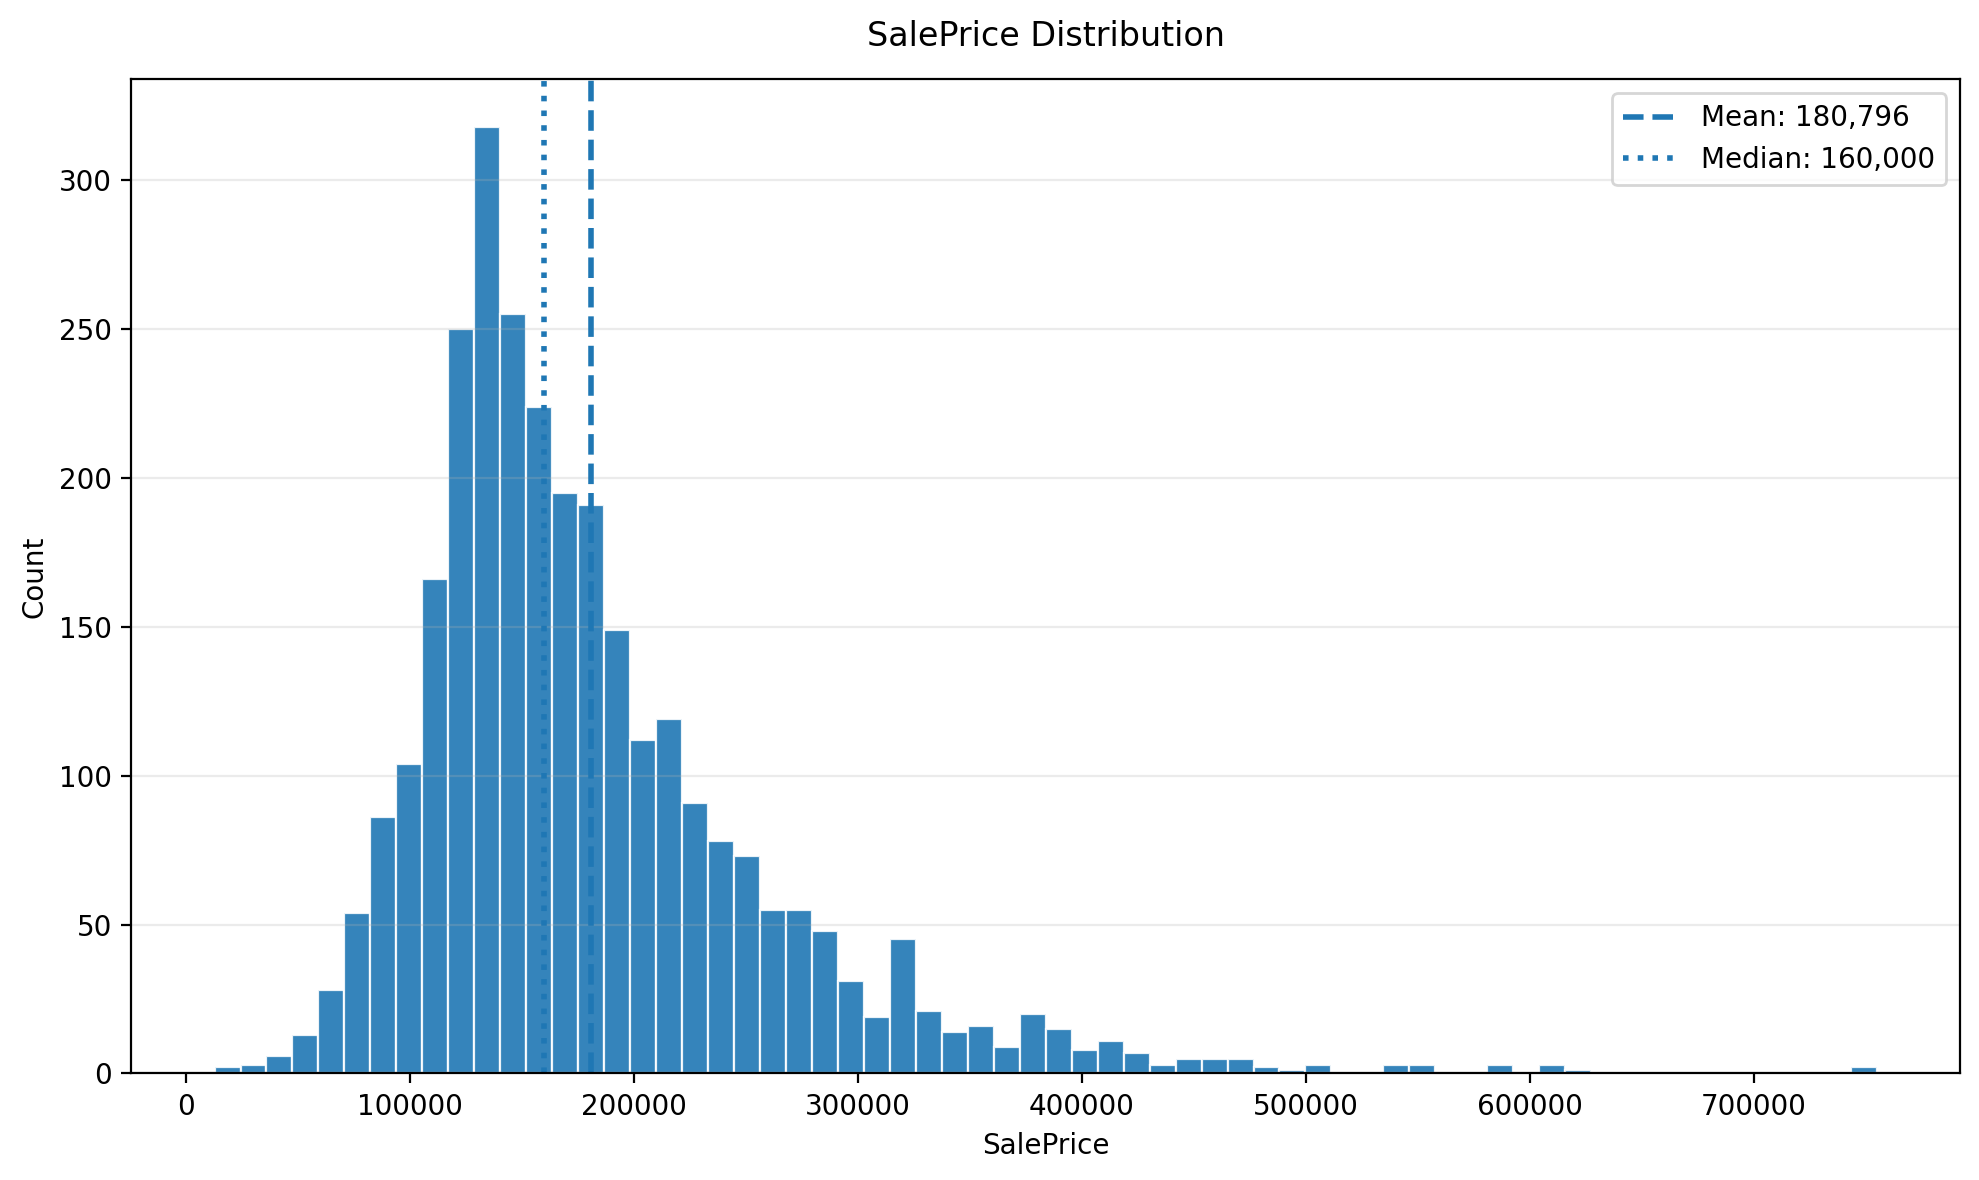

In [14]:
# --- Basic hygiene ---
saleprice = base_df["SalePrice"].dropna()

# --- Plot options (tweak as desired) ---
use_log_x = False          # True if SalePrice is heavily right-skewed
use_density = False        # True to show probability density instead of counts
show_mean_median = True    # Add mean/median reference lines
clip_outliers = False     # True to reduce the effect of extreme tails (view only)
clip_quantiles = (0.01, 0.99)  # used only if clip_outliers=True

# Choose bins automatically (Freedman–Diaconis) or set an int like 30/50/100
bins = "fd"  # alternatives: "auto", "sturges", 50, 100, etc.

# Optional: clip extreme values for a clearer view (doesn't change base_df)
if clip_outliers:
    lo, hi = saleprice.quantile(clip_quantiles)
    plot_data = saleprice.clip(lo, hi)
else:
    plot_data = saleprice

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

# Histogram
ax.hist(
    plot_data,
    bins=bins,
    density=use_density,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9
)

# Titles/labels
ax.set_title("SalePrice Distribution", pad=12)
ax.set_xlabel("SalePrice")
ax.set_ylabel("Density" if use_density else "Count")

# Grid (subtle)
ax.grid(True, axis="y", alpha=0.25)

# Optional: log scale on x-axis (helpful for right-skew)
if use_log_x:
    ax.set_xscale("log")
    ax.set_xlabel("SalePrice (log scale)")

# Optional: mean/median lines (use original non-clipped data so stats are honest)
if show_mean_median:
    mean_val = saleprice.mean()
    median_val = saleprice.median()
    ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean: {mean_val:,.0f}")
    ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median: {median_val:,.0f}")
    ax.legend()

plt.tight_layout()
plt.show()


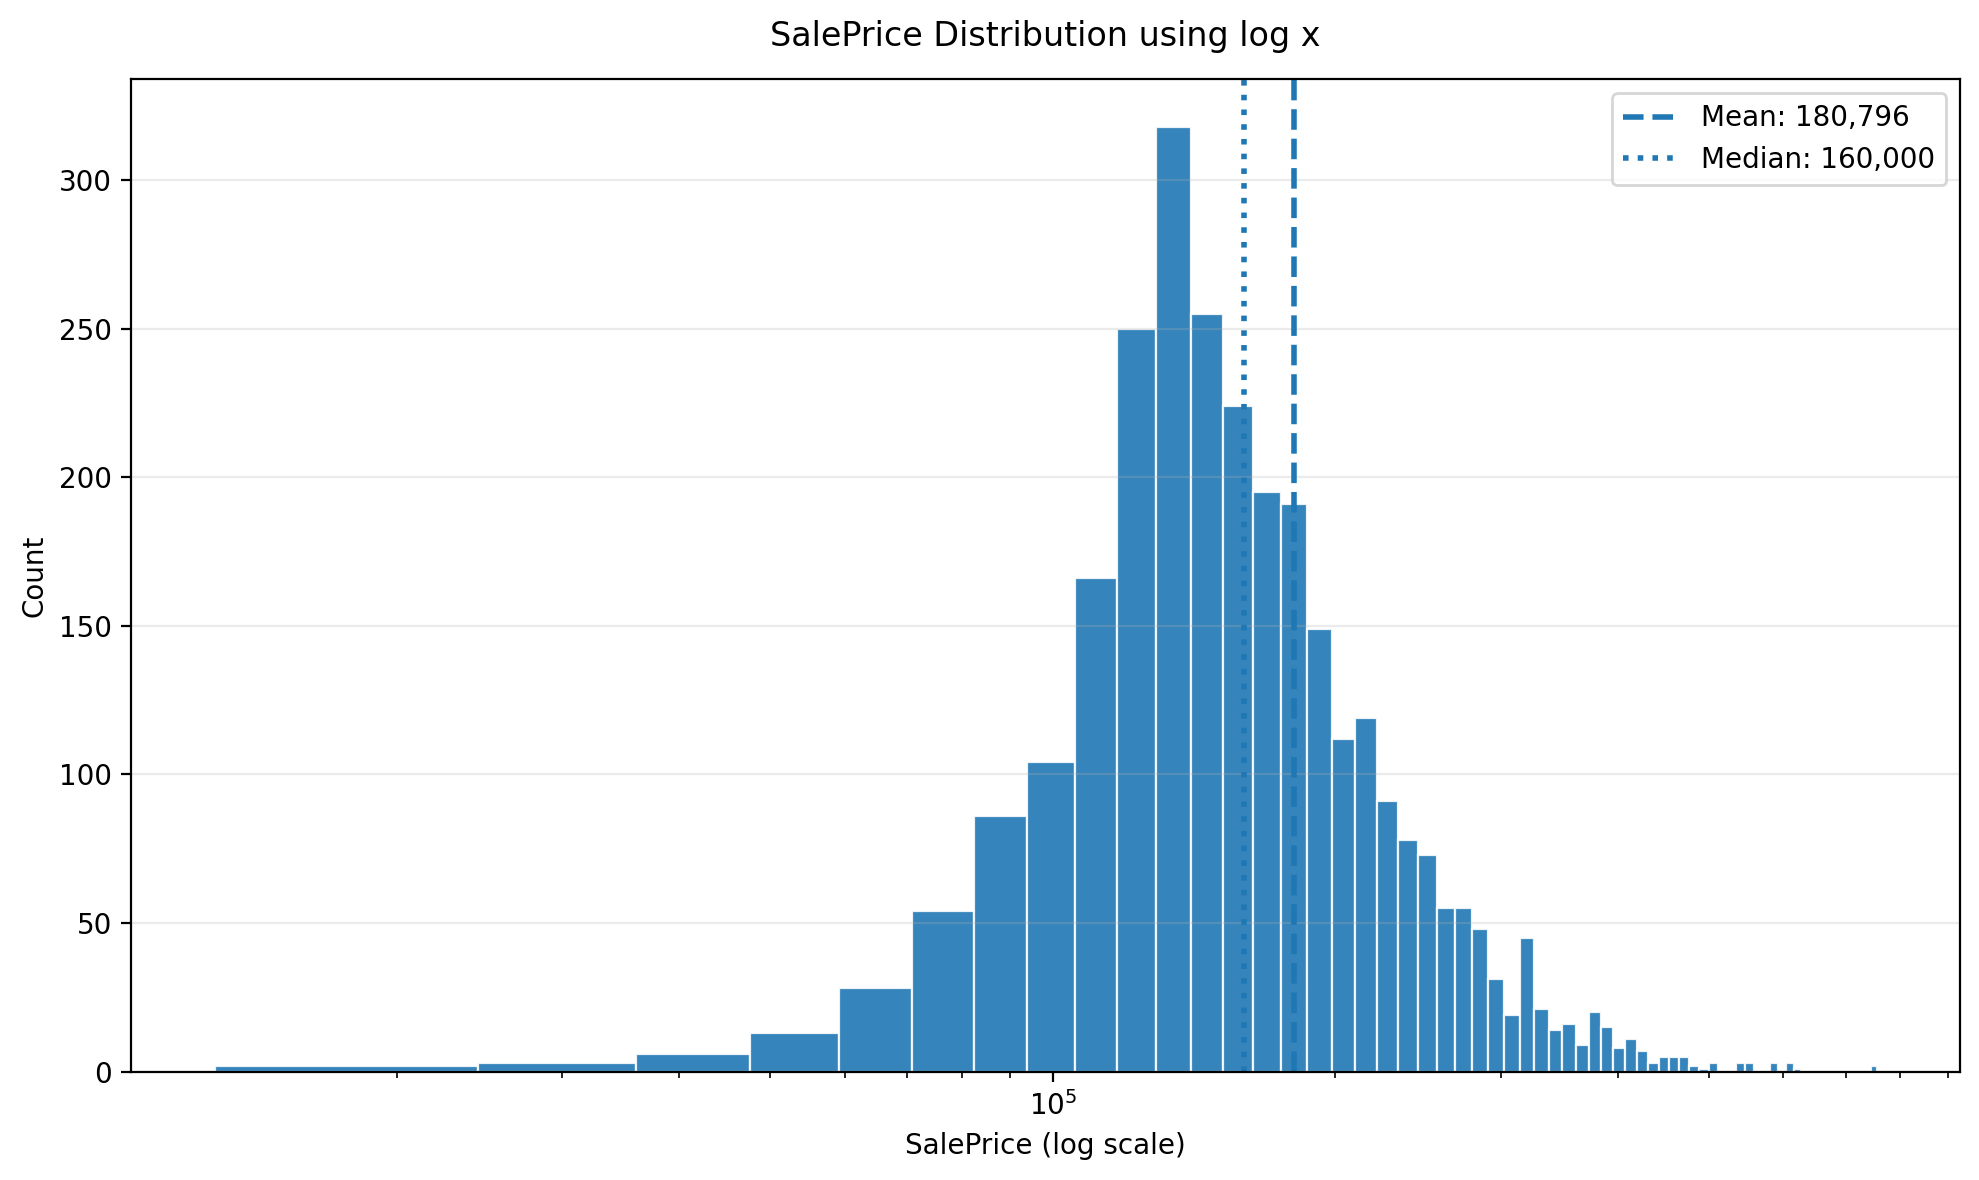

In [16]:
# --- Basic hygiene ---
saleprice = base_df["SalePrice"].dropna()

# --- Plot options (tweak as desired) ---
use_log_x = True          # True if SalePrice is heavily right-skewed
use_density = False        # True to show probability density instead of counts
show_mean_median = True    # Add mean/median reference lines
clip_outliers = False      # True to reduce the effect of extreme tails (view only)
clip_quantiles = (0.01, 0.99)  # used only if clip_outliers=True

# Choose bins automatically (Freedman–Diaconis) or set an int like 30/50/100
bins = "fd"  # alternatives: "auto", "sturges", 50, 100, etc.

# Optional: clip extreme values for a clearer view (doesn't change base_df)
if clip_outliers:
    lo, hi = saleprice.quantile(clip_quantiles)
    plot_data = saleprice.clip(lo, hi)
else:
    plot_data = saleprice

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

# Histogram
ax.hist(
    plot_data,
    bins=bins,
    density=use_density,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9
)

# Titles/labels
ax.set_title("SalePrice Distribution using log x", pad=12)
ax.set_xlabel("SalePrice")
ax.set_ylabel("Density" if use_density else "Count")

# Grid (subtle)
ax.grid(True, axis="y", alpha=0.25)

# Optional: log scale on x-axis (helpful for right-skew)
if use_log_x:
    ax.set_xscale("log")
    ax.set_xlabel("SalePrice (log scale)")

# Optional: mean/median lines (use original non-clipped data so stats are honest)
if show_mean_median:
    mean_val = saleprice.mean()
    median_val = saleprice.median()
    ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean: {mean_val:,.0f}")
    ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median: {median_val:,.0f}")
    ax.legend()

plt.tight_layout()
plt.show()
